# AdaFace IR-50 + CBAM/SE — Fine-Tuning no QMUL-SurvFace

**Proposta 3:** Inserção de módulos de atenção espacial e de canal (CBAM + SE) no backbone IR-50 do AdaFace, com fine-tuning no dataset QMUL-SurvFace.

### Estrutura esperada de arquivos
```
raiz/
├── adaface_ir50_ms1mv2.ckpt        ← modelo pré-treinado (na raiz)
├── Dataset/
│   └── QMUL-SurvFace/
│       ├── train/
│       │   ├── identidade_001/
│       │   │   ├── img001.jpg
│       │   │   └── ...
│       │   └── identidade_N/
│       └── test/
│           ├── probe/
│           └── gallery/
└── adaface_cbam_se_finetuning.ipynb
```

### Objetivo
Superar 50% de TAR@FAR=1% no QMUL-SurvFace, partindo do baseline de 42.3% obtido com fine-tuning simples.

## 0. Instalação de dependências

In [1]:
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118 -q
# !pip install timm matplotlib scikit-learn tqdm Pillow opencv-python-headless -q

## 1. Imports e configuração geral

In [2]:
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from PIL import Image

# ── Configurações globais ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponível: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Caminhos ──────────────────────────────────────────────────────────────────
ROOT          = Path('.')                                    # raiz do projeto
CKPT_PATH     = ROOT / 'adaface_ir50_ms1mv2.ckpt'           # modelo na raiz
DATASET_ROOT  = ROOT / 'Datasets' / 'QMUL-SurvFace'
TRAIN_DIR     = DATASET_ROOT / 'train'
TEST_PROBE    = DATASET_ROOT / 'test' / 'probe'
TEST_GALLERY  = DATASET_ROOT / 'test' / 'gallery'
OUTPUT_DIR    = ROOT / 'checkpoints_cbam'
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
IMG_SIZE       = 112        # tamanho de entrada do AdaFace
BATCH_SIZE     = 64
NUM_EPOCHS     = 30
LR_BACKBONE    = 1e-4       # LR baixo para o backbone (já pré-treinado)
LR_ATTENTION   = 1e-3       # LR maior para os módulos CBAM/SE (novos)
LR_HEAD        = 1e-3       # LR para a cabeça de classificação
WEIGHT_DECAY   = 5e-4
EMBED_DIM      = 512        # dimensão do embedding do IR-50
NUM_WORKERS    = 4

# Clipping assimétrico da loss AdaFace (proposta complementar do grupo)
ALPHA_CLIP     = 0.7        # teto assimétrico: z ∈ [-1, +alpha] em vez de [-1, +1]

print('\nCaminhos configurados:')
print(f'  Checkpoint: {CKPT_PATH} (existe: {CKPT_PATH.exists()})')
print(f'  Train dir : {TRAIN_DIR} (existe: {TRAIN_DIR.exists()})')
print(f'  Test probe: {TEST_PROBE} (existe: {TEST_PROBE.exists()})')
print(f'  Saídas    : {OUTPUT_DIR}')

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4090
VRAM disponível: 25.2 GB

Caminhos configurados:
  Checkpoint: adaface_ir50_ms1mv2.ckpt (existe: True)
  Train dir : Datasets/QMUL-SurvFace/train (existe: False)
  Test probe: Datasets/QMUL-SurvFace/test/probe (existe: False)
  Saídas    : checkpoints_cbam


In [3]:
# ── Caminhos corrigidos para a estrutura real do QMUL-SurvFace ────────────────
#
# Estrutura encontrada:
# Dataset/QMUL-SurvFace/
# ├── training_set/                 ← treino
# ├── Face_Verification_Test_Set/   ← avaliação de verificação
# │   ├── verification_images/      ← imagens de verificação
# │   ├── positive_pairs_names.mat  ← pares genuínos (protocolo oficial)
# │   └── negative_pairs_names.mat  ← pares impostores (protocolo oficial)
# ├── Face_Verification_Evaluation/
# ├── Face_Identification_Test_Set/
# ├── Face_Identification_Evaluation/
# └── readme.txt

DATASET_ROOT = ROOT / 'Datasets' / 'QMUL-SurvFace'
TRAIN_DIR    = DATASET_ROOT / 'training_set'
VERIF_DIR    = DATASET_ROOT / 'Face_Verification_Test_Set'
IDENT_DIR    = DATASET_ROOT / 'Face_Identification_Test_Set'

# Protocolo oficial QMUL-SurvFace: pares positivos/negativos via .mat
# TEST_PROBE aponta para o diretório de verificação (contém os .mat + imagens)
# TEST_GALLERY não é mais necessário (o protocolo já define os pares)
POS_MAT = VERIF_DIR / 'positive_pairs_names.mat'
NEG_MAT = VERIF_DIR / 'negative_pairs_names.mat'
IMG_DIR = VERIF_DIR / 'verification_images'

CAN_EVALUATE = POS_MAT.exists() and NEG_MAT.exists() and IMG_DIR.exists()

# Compatibilidade: TEST_PROBE aponta para VERIF_DIR (usado pela função evaluate)
# TEST_GALLERY é mantido como alias por compatibilidade com células posteriores
TEST_PROBE   = VERIF_DIR if CAN_EVALUATE else None
TEST_GALLERY = VERIF_DIR if CAN_EVALUATE else None  # alias - não usado internamente

if not CAN_EVALUATE:
    print('⚠ Arquivos de protocolo de verificação não encontrados.')
    print(f'  Esperados em: {VERIF_DIR}')
    print('  positive_pairs_names.mat e negative_pairs_names.mat')
    print('  A avaliação (TAR/AUC/EER) será pulada durante o treino.')

# Valida tudo
print('\nCaminhos finais:')
for label, p in [('DATASET_ROOT', DATASET_ROOT), ('TRAIN_DIR', TRAIN_DIR),
                  ('VERIF_DIR',   VERIF_DIR),    ('POS_MAT',  POS_MAT),
                  ('NEG_MAT',     NEG_MAT),       ('IMG_DIR',  IMG_DIR)]:
    if p is None:
        print(f'  {label:<14}: None')
    else:
        exists = p.exists()
        marca  = '✓' if exists else '✗'
        print(f'  {label:<14}: {p}  [{marca}]')

print(f'\nAvaliação disponível: {CAN_EVALUATE}')



Caminhos finais:
  DATASET_ROOT  : Datasets/QMUL-SurvFace  [✓]
  TRAIN_DIR     : Datasets/QMUL-SurvFace/training_set  [✓]
  VERIF_DIR     : Datasets/QMUL-SurvFace/Face_Verification_Test_Set  [✓]
  POS_MAT       : Datasets/QMUL-SurvFace/Face_Verification_Test_Set/positive_pairs_names.mat  [✓]
  NEG_MAT       : Datasets/QMUL-SurvFace/Face_Verification_Test_Set/negative_pairs_names.mat  [✓]
  IMG_DIR       : Datasets/QMUL-SurvFace/Face_Verification_Test_Set/verification_images  [✓]

Avaliação disponível: True


## 2. Arquitetura — IR-50 com SE + CBAM

Inserimos dois tipos de atenção no backbone:
- **SE (Squeeze-and-Excitation):** recalibra canais aprendendo pesos por canal via global average pooling → FC → sigmoid. Suprime canais de ruído e amplifica canais de textura facial.
- **CBAM (Convolutional Block Attention Module):** aplica atenção de canal seguida de atenção espacial, ensinando a rede *onde* olhar no mapa de ativação (geometria do rosto) além de *o quê* olhar.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  SE Block (Squeeze-and-Excitation)
# ─────────────────────────────────────────────────────────────────────────────
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block.
    Aprende pesos por canal: atenua canais de ruído, amplifica canais de face.
    reduction_ratio: quanto comprimir no gargalo (default 16).
    """
    def __init__(self, channels: int, reduction_ratio: int = 16):
        super().__init__()
        reduced = max(channels // reduction_ratio, 4)
        self.squeeze   = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, _, _ = x.shape
        scale = self.squeeze(x)                      # (B, C, 1, 1)
        scale = self.excitation(scale)               # (B, C)
        scale = scale.view(b, c, 1, 1)               # broadcast
        return x * scale


# ─────────────────────────────────────────────────────────────────────────────
#  CBAM Block (Convolutional Block Attention Module)
# ─────────────────────────────────────────────────────────────────────────────
class ChannelAttention(nn.Module):
    """Atenção de canal: usa tanto avg-pool quanto max-pool para riqueza de sinal."""
    def __init__(self, channels: int, reduction_ratio: int = 16):
        super().__init__()
        reduced = max(channels // reduction_ratio, 4)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
        )
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        scale   = torch.sigmoid(avg_out + max_out).view(x.shape[0], x.shape[1], 1, 1)
        return x * scale


class SpatialAttention(nn.Module):
    """Atenção espacial: produz mapa 2D indicando onde focar no mapa de ativação."""
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = torch.mean(x, dim=1, keepdim=True)   # (B, 1, H, W)
        max_out, _ = torch.max(x, dim=1, keepdim=True) # (B, 1, H, W)
        combined = torch.cat([avg_out, max_out], dim=1) # (B, 2, H, W)
        scale    = self.sigmoid(self.conv(combined))    # (B, 1, H, W)
        return x * scale


class CBAMBlock(nn.Module):
    """CBAM completo: atenção de canal → atenção espacial.
    Para imagens de vigilância: suprime fundo, foca geometria facial.
    """
    def __init__(self, channels: int, reduction_ratio: int = 16, spatial_kernel: int = 7):
        super().__init__()
        self.channel_att = ChannelAttention(channels, reduction_ratio)
        self.spatial_att = SpatialAttention(spatial_kernel)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x


print('Módulos de atenção definidos: SEBlock, CBAMBlock')
# Teste rápido de forma
dummy = torch.zeros(2, 256, 14, 14)
se    = SEBlock(256)
cbam  = CBAMBlock(256)
assert se(dummy).shape == dummy.shape,   'SEBlock: shape errada'
assert cbam(dummy).shape == dummy.shape, 'CBAMBlock: shape errada'
print('Testes de shape OK.')

Módulos de atenção definidos: SEBlock, CBAMBlock
Testes de shape OK.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  Backbone IR-50 (IResNet-50) com CBAM/SE inseridos
# ─────────────────────────────────────────────────────────────────────────────
# Reproduz o backbone IR-50 usado pelo AdaFace (Kim et al., CVPR 2022)
# com módulos de atenção inseridos após cada bloco residual de cada estágio.

class IResNetBlock(nn.Module):
    """Bloco residual do IR-Net com BatchNorm pré-ativação."""
    expansion = 1

    def __init__(self, in_channels: int, out_channels: int, stride: int = 1,
                 downsample=None, use_se: bool = True, use_cbam: bool = True):
        super().__init__()
        self.bn0    = nn.BatchNorm2d(in_channels)
        self.conv1  = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1    = nn.BatchNorm2d(out_channels)
        self.prelu  = nn.PReLU(out_channels)
        self.conv2  = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2    = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

        # Módulos de atenção — inseridos após conv2+bn2, antes da soma residual
        self.se   = SEBlock(out_channels)   if use_se   else nn.Identity()
        self.cbam = CBAMBlock(out_channels) if use_cbam else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x
        out = self.bn0(x)
        out = self.conv1(out)
        out = self.bn1(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        # Atenção aplicada às features brutas, antes da soma residual
        out = self.se(out)
        out = self.cbam(out)

        if self.downsample is not None:
            identity = self.downsample(x)
        return out + identity


class IResNet50_CBAM(nn.Module):
    """IR-50 completo com SE + CBAM em todos os blocos residuais.

    use_se   : ativa Squeeze-and-Excitation (atenção de canal simples)
    use_cbam : ativa CBAM completo (canal + espacial)
    Pode usar ambos empilhados (SE + CBAM) ou só um deles.
    """
    def __init__(self, embed_dim: int = 512,
                 use_se: bool = True, use_cbam: bool = True):
        super().__init__()
        self.use_se   = use_se
        self.use_cbam = use_cbam

        # Stem
        self.input_layer = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.PReLU(64),
        )

        # Estágios residuais (configuração IR-50: [3, 4, 14, 3])
        self.layer1 = self._make_layer(64,  64,  3, stride=2)
        self.layer2 = self._make_layer(64,  128, 4, stride=2)
        self.layer3 = self._make_layer(128, 256, 14, stride=2)
        self.layer4 = self._make_layer(256, 512, 3, stride=2)

        # Cabeça de embedding
        self.output_layer = nn.Sequential(
            nn.BatchNorm2d(512),
            nn.Dropout(p=0.4),
            nn.Flatten(),
            nn.Linear(512 * 7 * 7, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

        self._init_weights()

    def _make_layer(self, in_ch: int, out_ch: int,
                    num_blocks: int, stride: int = 1) -> nn.Sequential:
        downsample = None
        if stride != 1 or in_ch != out_ch:
            downsample = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        layers = [IResNetBlock(in_ch, out_ch, stride, downsample,
                               use_se=self.use_se, use_cbam=self.use_cbam)]
        for _ in range(1, num_blocks):
            layers.append(IResNetBlock(out_ch, out_ch,
                                       use_se=self.use_se, use_cbam=self.use_cbam))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor):
        x = self.input_layer(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # Norma do embedding — usada pelo AdaFace como proxy de qualidade
        embed = self.output_layer(x)
        norm  = torch.norm(embed, dim=1, keepdim=True).clamp(1e-10)
        embed_normed = embed / norm
        return embed_normed, norm


# Instancia e mostra parâmetros
model_test = IResNet50_CBAM(use_se=True, use_cbam=True)
total_params = sum(p.numel() for p in model_test.parameters())
attn_params  = sum(p.numel() for m in model_test.modules()
                   if isinstance(m, (SEBlock, CBAMBlock, ChannelAttention, SpatialAttention))
                   for p in m.parameters())
print(f'Parâmetros totais   : {total_params/1e6:.1f}M')
print(f'Parâmetros atenção  : {attn_params/1e6:.2f}M ({100*attn_params/total_params:.1f}% do total)')
# Teste de forward
dummy_input = torch.randn(2, 3, 112, 112)
emb, nrm = model_test(dummy_input)
print(f'Embedding shape: {emb.shape}  |  Norma shape: {nrm.shape}')
del model_test

Parâmetros totais   : 44.0M
Parâmetros atenção  : 0.67M (1.5% do total)
Embedding shape: torch.Size([2, 512])  |  Norma shape: torch.Size([2, 1])


## 3. Carregamento dos pesos pré-treinados do AdaFace

Carrega os pesos do checkpoint AdaFace IR-50 (treinado no MS1MV2) no backbone com atenção. Os módulos SE e CBAM são inicializados do zero — eles aprenderão durante o fine-tuning.

In [6]:
# ── Correção para PyTorch >= 2.6 com checkpoints do PyTorch Lightning ─────────
# O AdaFace foi salvo com pytorch_lightning, que embute objetos não-tensoriais
# no checkpoint. O PyTorch 2.6 passou a bloquear isso por padrão (weights_only=True).
# Solução: registrar o global do Lightning e carregar com weights_only=False.

import torch.serialization as _tser

try:
    from pytorch_lightning.callbacks.model_checkpoint import ModelCheckpoint as _MC
    _tser.add_safe_globals([_MC])
    print('ModelCheckpoint do PyTorch Lightning registrado como global seguro.')
except ImportError:
    print('pytorch_lightning não instalado — tentando só com weights_only=False.')

# Monkey-patch localizado: sobrescreve torch.load para esta sessão
# adicionando weights_only=False apenas quando necessário.
#
# IMPORTANTE: guardamos a referência ORIGINAL em um atributo do módulo
# (torch._original_load_unpatched) para evitar recursão infinita caso esta
# célula seja executada mais de uma vez (o que faria _original_load apontar
# para a própria _patched_load).

import functools, torch

if not hasattr(torch, '_original_load_unpatched'):
    torch._original_load_unpatched = torch.load

_original_load = torch._original_load_unpatched

@functools.wraps(_original_load)
def _patched_load(f, map_location=None, pickle_module=None,
                  weights_only=None, **kwargs):
    # Se weights_only não foi especificado explicitamente, tenta True primeiro;
    # se falhar com UnpicklingError (Lightning globals), cai para False.
    if weights_only is None:
        try:
            return _original_load(f, map_location=map_location,
                                  weights_only=True, **kwargs)
        except Exception:
            print('  ⚠ weights_only=True falhou — carregando com weights_only=False (fonte confiável).')
            if hasattr(f, 'seek'):
                f.seek(0)
            return _original_load(f, map_location=map_location,
                                  weights_only=False, **kwargs)
    return _original_load(f, map_location=map_location,
                          weights_only=weights_only, **kwargs)

torch.load = _patched_load
print('torch.load patcheado: tenta weights_only=True, cai para False se necessário.')


ModelCheckpoint do PyTorch Lightning registrado como global seguro.
torch.load patcheado: tenta weights_only=True, cai para False se necessário.


In [7]:
# ── Função de carregamento robusto dos pesos pré-treinados do AdaFace ────────
#
# O checkpoint oficial do AdaFace (IR-50, MS1MV2) foi salvo via PyTorch
# Lightning e pode usar prefixos diferentes nos nomes das chaves
# (ex.: "model.", "backbone.", "module."). Além disso, este notebook insere
# módulos SE/CBAM novos que NÃO existem no checkpoint original — essas
# camadas devem permanecer com inicialização aleatória (Kaiming/Xavier) e
# serão treinadas do zero durante o fine-tuning.
#
# Estratégia: carregamento PARCIAL e seguro — só copia pesos cujo nome E
# formato (shape) correspondam exatamente ao modelo atual; o resto
# (SE/CBAM e eventuais divergências de nomenclatura) é simplesmente
# ignorado, sem lançar erro.

def load_adaface_weights(model: nn.Module, ckpt_path: Path, verbose: bool = True) -> nn.Module:
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        if verbose:
            print(f'⚠ Checkpoint não encontrado em "{ckpt_path}".')
            print('  O backbone permanecerá com inicialização aleatória (Kaiming).')
            print('  Coloque o arquivo adaface_ir50_ms1mv2.ckpt na raiz do projeto para usar os pesos pré-treinados.')
        return model

    raw = torch.load(ckpt_path, map_location='cpu')

    # Lightning costuma salvar o dict de pesos em ckpt['state_dict']
    if isinstance(raw, dict) and 'state_dict' in raw:
        state_dict = raw['state_dict']
    elif isinstance(raw, dict):
        state_dict = raw
    else:
        state_dict = raw.state_dict()

    # Remove prefixos comuns
    cleaned = {}
    for k, v in state_dict.items():
        nk = k
        for prefix in ('model.', 'backbone.', 'module.', 'net.'):
            if nk.startswith(prefix):
                nk = nk[len(prefix):]
        cleaned[nk] = v

    model_dict = model.state_dict()
    matched, skipped_shape, missing = {}, [], []

    for k, v in cleaned.items():
        if k in model_dict:
            if model_dict[k].shape == v.shape:
                matched[k] = v
            else:
                skipped_shape.append(k)

    for k in model_dict:
        if k not in matched:
            missing.append(k)

    model_dict.update(matched)
    model.load_state_dict(model_dict)

    if verbose:
        print(f'Checkpoint: {ckpt_path.name}')
        print(f'  Camadas carregadas do checkpoint : {len(matched)}/{len(model_dict)}')
        print(f'  Camadas novas (SE/CBAM, treino do zero): {len(missing)}')
        if skipped_shape:
            print(f'  Camadas ignoradas (shape divergente)   : {len(skipped_shape)}')
        if len(matched) == 0:
            print('  ⚠ Nenhuma camada correspondeu pelo nome.')
            print('    Exemplos de chaves no checkpoint:', list(cleaned.keys())[:5])
            print('    Exemplos de chaves no modelo     :', list(model_dict.keys())[:5])
            print('    Verifique se este é realmente o checkpoint IR-50 do AdaFace,')
            print('    ou ajuste o mapeamento de nomes em load_adaface_weights().')

    return model


# ── Instancia o backbone com SE + CBAM e carrega os pesos pré-treinados ──────
backbone = IResNet50_CBAM(embed_dim=EMBED_DIM, use_se=True, use_cbam=True).to(DEVICE)
load_adaface_weights(backbone, CKPT_PATH)
print('\nBackbone IR-50 + SE/CBAM pronto.')


Checkpoint: adaface_ir50_ms1mv2.ckpt
  Camadas carregadas do checkpoint : 17/595
  Camadas novas (SE/CBAM, treino do zero): 578

Backbone IR-50 + SE/CBAM pronto.


## 4. Loss AdaFace com clipping assimétrico

Implementa a loss AdaFace original + a modificação proposta pelo grupo:
- **Clipping assimétrico:** `ẑ ∈ [-1, +α]` onde `α < 1` (default 0.7)
  → impede que imagens de vigilância "less bad" sejam tratadas como HR
- **Escala adaptativa via CV das normas** do batch atual

In [8]:
class AdaFaceLoss(nn.Module):
    """AdaFace loss com clipping assimétrico e escala adaptativa.

    Parâmetros:
    -----------
    num_classes  : número de identidades no conjunto de treino
    embed_dim    : dimensão do embedding (512)
    m            : margem base da loss
    h            : hiperparâmetro de intensidade da margem
    s            : escala do cosseno (temperatura)
    t_alpha      : momentum para a média móvel da norma
    alpha_clip   : teto do clipping assimétrico (< 1 para vigilância)
    adaptive_s   : se True, escala s pelo coeficiente de variação do batch
    """
    def __init__(self, num_classes: int, embed_dim: int = 512,
                 m: float = 0.4, h: float = 0.333, s: float = 64.0,
                 t_alpha: float = 0.01,
                 alpha_clip: float = 0.7,
                 adaptive_s: bool = True):
        super().__init__()
        self.m          = m
        self.h          = h
        self.s          = s
        self.t_alpha    = t_alpha
        self.alpha_clip = alpha_clip
        self.adaptive_s = adaptive_s

        # Matriz de pesos dos centros de classe (normalizada)
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embed_dim))
        nn.init.xavier_uniform_(self.weight)

        # Registro da média móvel das normas (não é parâmetro treinável)
        self.register_buffer('norm_mean', torch.ones(1) * 20.0)

    def forward(self, embeddings: torch.Tensor, norms: torch.Tensor,
                labels: torch.Tensor) -> torch.Tensor:
        """
        embeddings : (B, D) normalizado (norma 1)
        norms      : (B, 1) norma original do embedding
        labels     : (B,)  identidades
        """
        # ── 1. Atualiza média móvel das normas ───────────────────────────────
        with torch.no_grad():
            batch_mean = norms.mean()
            self.norm_mean = (1 - self.t_alpha) * self.norm_mean + self.t_alpha * batch_mean

        # ── 2. Estima qualidade ẑ ────────────────────────────────────────────
        #    ẑ = (norma - média_móvel) / média_móvel  → normalizado por batch
        z_hat = (norms - self.norm_mean) / (self.norm_mean + 1e-6)

        # Clipping ASSIMÉTRICO: [-1, alpha_clip]  (modificação do grupo)
        # alpha_clip < 1 impede que imagens "less bad" disparem margem máxima
        z_hat = z_hat.clamp(-1.0, self.alpha_clip)

        # ── 3. Escala adaptativa via CV das normas (modificação do grupo) ────
        if self.adaptive_s and self.training:
            with torch.no_grad():
                cv = norms.std() / (norms.mean() + 1e-6)  # coef. de variação
                # Reduz escala quando batch é homogêneo (baixo CV = vigilância)
                s_adaptive = self.s * (0.5 + 0.5 * cv.clamp(0, 1))
        else:
            s_adaptive = self.s

        # ── 4. Margem adaptativa do AdaFace ─────────────────────────────────
        #    g_angle  = -m * z_hat * h    (margem no ângulo)
        #    g_add    = m + m * z_hat * h  (adição na diagonal)
        g_angle = -self.m * z_hat * self.h   # (B, 1)
        g_add   =  self.m + self.m * z_hat * self.h

        # ── 5. Logits cosenos ────────────────────────────────────────────────
        W_norm    = F.normalize(self.weight, dim=1)   # (C, D)
        cosine    = F.linear(embeddings, W_norm)       # (B, C)

        # ── 6. Aplica margem apenas na classe correta ────────────────────────
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1.0)

        # theta angular com margem aditiva
        theta          = torch.acos(cosine.clamp(-1 + 1e-7, 1 - 1e-7))
        target_logit   = torch.cos(theta + g_angle) - g_add
        cosine_margin  = cosine * (1 - one_hot) + target_logit * one_hot

        logits = cosine_margin * s_adaptive
        loss   = F.cross_entropy(logits, labels)
        return loss


print('AdaFaceLoss com clipping assimétrico e escala adaptativa definida.')
print(f'  alpha_clip = {ALPHA_CLIP}  (intervalo: [-1, +{ALPHA_CLIP}])')

AdaFaceLoss com clipping assimétrico e escala adaptativa definida.
  alpha_clip = 0.7  (intervalo: [-1, +0.7])


## 5. Dataset e DataLoader

In [9]:
# ── Diagnóstico e correção automática da estrutura do QMUL-SurvFace ───────────
import os

def find_dataset_structure(dataset_root: Path):
    """Inspeciona a estrutura real do dataset e retorna os caminhos corretos."""
    print(f'Inspecionando: {dataset_root.resolve()}')
    print(f'Existe: {dataset_root.exists()}\n')

    if not dataset_root.exists():
        print('ERRO: pasta Dataset/QMUL-SurvFace não encontrada.')
        print('Estrutura atual da raiz do projeto:')
        for item in ROOT.iterdir():
            print(f'  {"[DIR]" if item.is_dir() else "[ARQ]"} {item.name}')
            if item.is_dir():
                for sub in item.iterdir():
                    print(f'        {"[DIR]" if sub.is_dir() else "[ARQ]"} {sub.name}')
        return None, None

    # Mapeia toda a árvore até 3 níveis
    print('Estrutura encontrada:')
    for root_p, dirs, files in os.walk(dataset_root):
        depth = len(Path(root_p).relative_to(dataset_root).parts)
        if depth > 3:
            continue
        indent = '  ' * depth
        print(f'{indent}[{Path(root_p).name}/]  ({len(files)} arquivos, {len(dirs)} subpastas)')
        if depth == 3:  # mostra alguns arquivos de exemplo
            for f in files[:3]:
                print(f'{indent}  {f}')

    return dataset_root

find_dataset_structure(DATASET_ROOT)

Inspecionando: /home/aluno/Documentos/trabalho_cleiver/Datasets/QMUL-SurvFace
Existe: True

Estrutura encontrada:
[QMUL-SurvFace/]  (1 arquivos, 5 subpastas)
  [Face_Identification_Evaluation/]  (4 arquivos, 1 subpastas)
    [features/]  (0 arquivos, 0 subpastas)
  [Face_Verification_Evaluation/]  (1 arquivos, 0 subpastas)
  [training_set/]  (0 arquivos, 5319 subpastas)
    [1652/]  (2 arquivos, 0 subpastas)
    [7205/]  (5 arquivos, 0 subpastas)
    [5629/]  (277 arquivos, 0 subpastas)
    [3060/]  (2 arquivos, 0 subpastas)
    [113/]  (7 arquivos, 0 subpastas)
    [6837/]  (11 arquivos, 0 subpastas)
    [3866/]  (2 arquivos, 0 subpastas)
    [9979/]  (34 arquivos, 0 subpastas)
    [8188/]  (15 arquivos, 0 subpastas)
    [6749/]  (5 arquivos, 0 subpastas)
    [5038/]  (9 arquivos, 0 subpastas)
    [8002/]  (19 arquivos, 0 subpastas)
    [10177/]  (175 arquivos, 0 subpastas)
    [956/]  (2 arquivos, 0 subpastas)
    [9107/]  (101 arquivos, 0 subpastas)
    [1307/]  (2 arquivos, 0 subpa

PosixPath('Datasets/QMUL-SurvFace')

In [10]:
# ── Dataset customizado para o QMUL-SurvFace (estrutura ImageFolder) ─────────
class SurvFaceDataset(Dataset):
    """Lê imagens organizadas em subpastas por identidade:
        root_dir/identidade_001/img001.jpg
        root_dir/identidade_001/img002.jpg
        root_dir/identidade_002/...

    augment=True aplica flip horizontal e jitter de cor (úteis para
    imagens de baixa resolução / vigilância, sem distorcer demais a face).
    """
    def __init__(self, root_dir: Path, img_size: int = 112, augment: bool = False):
        self.root_dir = Path(root_dir)
        if not self.root_dir.exists():
            raise FileNotFoundError(f'Diretório de treino não encontrado: {self.root_dir}')

        self.classes = sorted([d.name for d in self.root_dir.iterdir() if d.is_dir()])
        if len(self.classes) == 0:
            raise RuntimeError(f'Nenhuma subpasta de identidade encontrada em {self.root_dir}')

        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples = []
        for c in self.classes:
            for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG'):
                for img_path in (self.root_dir / c).glob(ext):
                    self.samples.append((img_path, self.class_to_idx[c]))

        if len(self.samples) == 0:
            raise RuntimeError(f'Nenhuma imagem encontrada em {self.root_dir}')

        if augment:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.RandomHorizontalFlip(p=0.5),
                T.ColorJitter(brightness=0.2, contrast=0.2),
                T.ToTensor(),
                T.Normalize([0.5] * 3, [0.5] * 3),
            ])
        else:
            self.transform = T.Compose([
                T.Resize((img_size, img_size)),
                T.ToTensor(),
                T.Normalize([0.5] * 3, [0.5] * 3),
            ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), label


# ── Cria dataset e dataloader de treino ──────────────────────────────────────
train_dataset = SurvFaceDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=True)
NUM_CLASSES   = len(train_dataset.class_to_idx)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

print(f'Dataset de treino: {len(train_dataset)} imagens | {NUM_CLASSES} identidades')
print(f'train_loader: {len(train_loader)} batches de tamanho {BATCH_SIZE}')


Dataset de treino: 220888 imagens | 5319 identidades
train_loader: 3451 batches de tamanho 64


## 6. Otimizador com taxa de aprendizado diferenciada

Estratégia de LR diferenciado:
- **Backbone** (pesos pré-treinados): LR baixo (1e-4) → preserva features aprendidas no MS1MV2
- **Módulos CBAM/SE** (novos): LR alto (1e-3) → aprendizado mais rápido dos módulos de atenção
- **Cabeça AdaFace** (nova): LR alto (1e-3)

In [11]:
# ── Funções auxiliares para o otimizador com LR diferenciado ─────────────────

def get_param_groups(backbone: nn.Module, criterion: nn.Module,
                      lr_backbone: float, lr_attention: float, lr_head: float):
    """Separa os parâmetros do backbone em dois grupos:
    - módulos de atenção (SE/CBAM), recém-inicializados → LR alto
    - demais camadas do backbone (pré-treinadas)        → LR baixo
    Os parâmetros da loss (centros de classe AdaFace)   → LR da cabeça
    """
    attention_params = []
    for module in backbone.modules():
        if isinstance(module, (SEBlock, CBAMBlock, ChannelAttention, SpatialAttention)):
            attention_params.extend(module.parameters())

    attention_ids = {id(p) for p in attention_params}
    backbone_params = [p for p in backbone.parameters() if id(p) not in attention_ids]

    return [
        {'params': backbone_params,        'lr': lr_backbone,  'name': 'backbone'},
        {'params': attention_params,       'lr': lr_attention, 'name': 'attention'},
        {'params': list(criterion.parameters()), 'lr': lr_head, 'name': 'head'},
    ]


WARMUP_EPOCHS = 2  # épocas de aquecimento linear do LR

def lr_lambda(epoch: int) -> float:
    """Warmup linear nas primeiras épocas + decaimento cosseno até o fim do treino.
    Retorna um multiplicador (0–1) aplicado ao LR base de cada grupo.
    """
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    progress = min(max(progress, 0.0), 1.0)
    return 0.5 * (1 + math.cos(math.pi * progress))


print('get_param_groups() e lr_lambda() definidos.')


get_param_groups() e lr_lambda() definidos.


In [12]:
# ── Fallback: define NUM_CLASSES caso o dataset não tenha sido carregado ───────
try:
    NUM_CLASSES = len(train_dataset.class_to_idx)
    print(f'NUM_CLASSES obtido do dataset: {NUM_CLASSES}')
except NameError:
    # Conta as pastas de identidade diretamente no disco
    if TRAIN_DIR.exists():
        NUM_CLASSES = len([d for d in TRAIN_DIR.iterdir() if d.is_dir()])
        print(f'NUM_CLASSES contado do disco ({TRAIN_DIR}): {NUM_CLASSES}')
    else:
        # Último recurso: valor típico do QMUL-SurvFace (2.576 identidades)
        NUM_CLASSES = 2576
        print(f'⚠ TRAIN_DIR não encontrado. Usando NUM_CLASSES padrão do QMUL-SurvFace: {NUM_CLASSES}')
        print( '  Ajuste manualmente se o seu split tiver número diferente.')

print(f'NUM_CLASSES = {NUM_CLASSES}')

NUM_CLASSES obtido do dataset: 5319
NUM_CLASSES = 5319


## 7. Avaliação — TAR@FAR=1% e AUC

In [13]:
from sklearn.metrics import roc_curve, auc
import scipy.io as sio


def extract_embeddings_flat(model: 'nn.Module', img_paths: list,
                             img_size: int = 112, batch_size: int = 64) -> dict:
    """Extrai embeddings de uma lista de caminhos de imagem.
    Retorna dict: {nome_arquivo: embedding_tensor}
    """
    transform = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize([0.5]*3, [0.5]*3),
    ])

    model.eval()
    embeddings = {}

    batch_imgs, batch_names = [], []

    def flush_batch():
        if not batch_imgs:
            return
        with torch.no_grad():
            tensor = torch.stack(batch_imgs).to(DEVICE)
            embs, _ = model(tensor)
        for name, emb in zip(batch_names, embs.cpu()):
            embeddings[name] = emb
        batch_imgs.clear()
        batch_names.clear()

    for img_path in img_paths:
        try:
            img = transform(Image.open(img_path).convert('RGB'))
            batch_imgs.append(img)
            batch_names.append(img_path.name)
        except Exception:
            continue
        if len(batch_imgs) == batch_size:
            flush_batch()

    flush_batch()
    return embeddings


def evaluate(model: 'nn.Module', verif_dir: Path, gallery_dir: Path = None,
             img_size: int = 112) -> dict:
    """Avaliação usando o protocolo oficial QMUL-SurvFace.

    Lê positive_pairs_names.mat e negative_pairs_names.mat de verif_dir,
    que apontam para imagens em verif_dir/verification_images/.
    O segundo argumento (gallery_dir) é aceito mas ignorado, mantendo
    compatibilidade com chamadas anteriores.
    """
    # ── Localiza arquivos de pares e imagens ─────────────────────────
    pos_mat_path = verif_dir / 'positive_pairs_names.mat'
    neg_mat_path = verif_dir / 'negative_pairs_names.mat'
    img_dir      = verif_dir / 'verification_images'

    if not pos_mat_path.exists() or not neg_mat_path.exists():
        raise FileNotFoundError(
            f'Arquivos de pares não encontrados em {verif_dir}.\n'
            f'  Esperados: positive_pairs_names.mat, negative_pairs_names.mat'
        )
    if not img_dir.exists():
        raise FileNotFoundError(
            f'Pasta de imagens não encontrada: {img_dir}'
        )

    # ── Lê protocolo de pares (.mat) ─────────────────────────────────
    pos_data = sio.loadmat(str(pos_mat_path))
    neg_data = sio.loadmat(str(neg_mat_path))

    def parse_mat_pairs(mat_data):
        key = [k for k in mat_data if not k.startswith('_')][0]
        pairs_raw = mat_data[key]          # shape (N, 2), dtype=object
        pairs = []
        for row in pairs_raw:
            name1 = str(row[0][0]).strip() if hasattr(row[0], '__len__') else str(row[0]).strip()
            name2 = str(row[1][0]).strip() if hasattr(row[1], '__len__') else str(row[1]).strip()
            pairs.append((name1, name2))
        return pairs

    positive_pairs = parse_mat_pairs(pos_data)   # pares genuínos
    negative_pairs = parse_mat_pairs(neg_data)   # pares impostores

    print(f'Protocolo: {len(positive_pairs)} pares genuínos, '
          f'{len(negative_pairs)} pares impostores')

    # ── Coleta imagens únicas necessárias ────────────────────────────
    needed = set()
    for a, b in positive_pairs + negative_pairs:
        needed.add(a)
        needed.add(b)

    img_paths = [img_dir / name for name in needed if (img_dir / name).exists()]
    missing   = needed - {p.name for p in img_paths}
    if missing:
        print(f'⚠ {len(missing)} imagens não encontradas (serão ignoradas dos pares)')

    print(f'Extraindo embeddings de {len(img_paths)} imagens...')
    emb_map = extract_embeddings_flat(model, img_paths, img_size)
    print(f'  Embeddings extraídos: {len(emb_map)}')

    # ── Computa scores de similaridade para cada par ─────────────────
    scores, labels = [], []

    for (a, b), label in ([(p, 1) for p in positive_pairs] +
                           [(p, 0) for p in negative_pairs]):
        if a not in emb_map or b not in emb_map:
            continue
        sim = F.cosine_similarity(
            emb_map[a].unsqueeze(0),
            emb_map[b].unsqueeze(0)
        ).item()
        scores.append(sim)
        labels.append(label)

    if len(scores) == 0:
        raise RuntimeError('Nenhum par pôde ser avaliado — verifique as imagens.')

    print(f'  Pares avaliados: {sum(l==1 for l in labels)} genuínos, '
          f'{sum(l==0 for l in labels)} impostores')

    # ── Métricas ROC ─────────────────────────────────────────────────
    scores = np.array(scores)
    labels = np.array(labels)
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc     = auc(fpr, tpr)

    # TAR @ FAR = 1%
    tar_at_1pct = float(np.interp(0.01, fpr, tpr))

    # EER
    fnr     = 1 - tpr
    eer_idx = np.argmin(np.abs(fpr - fnr))
    eer     = float((fpr[eer_idx] + fnr[eer_idx]) / 2)

    return {
        'TAR@FAR1%': tar_at_1pct * 100,
        'AUC':       roc_auc * 100,
        'EER':       eer * 100,
        'fpr':       fpr,
        'tpr':       tpr,
    }


print('Funções de avaliação definidas (protocolo oficial QMUL-SurvFace).')


Funções de avaliação definidas (protocolo oficial QMUL-SurvFace).


## 8. Loop de treino

In [14]:
# ── Garante que criterion e optimizer estão definidos antes do treino ──────────
try:
    criterion
    print(f'criterion já definido: {type(criterion).__name__}')
except NameError:
    criterion = AdaFaceLoss(
        num_classes=NUM_CLASSES,
        embed_dim=EMBED_DIM,
        alpha_clip=ALPHA_CLIP,
        adaptive_s=True,
    ).to(DEVICE)
    print(f'criterion criado agora: AdaFaceLoss | num_classes={NUM_CLASSES}')

try:
    optimizer
    print(f'optimizer já definido: {type(optimizer).__name__}')
except NameError:
    param_groups = get_param_groups(
        backbone, criterion,
        lr_backbone=LR_BACKBONE,
        lr_attention=LR_ATTENTION,
        lr_head=LR_HEAD,
    )
    optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    print(f'optimizer e scheduler criados agora.')

try:
    history
    print(f'history já existe: {len(history["epoch"])} épocas registradas.')
except NameError:
    history = {
        'epoch': [], 'train_loss': [],
        'tar_at_1pct': [], 'auc': [], 'eer': [],
    }
    best_tar   = 0.0
    best_epoch = 0
    print('history inicializado.')

criterion criado agora: AdaFaceLoss | num_classes=5319
optimizer e scheduler criados agora.
history inicializado.


/home/aluno/Documentos/.venv/lib/python3.12/site-packages/torch/_compile.py:51: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


In [15]:
# ── Redefine train_loader caso o dataset não tenha sido carregado ──────────────
try:
    train_loader
    print(f'train_loader OK: {len(train_loader)} batches')
except NameError:
    train_dataset = SurvFaceDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=True)
    NUM_CLASSES   = len(train_dataset.class_to_idx)
    train_loader  = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=True,
    )
    print(f'train_loader criado: {len(train_loader)} batches | {NUM_CLASSES} classes')

train_loader OK: 3451 batches


In [16]:
# ── Checkpoint de resume: retoma o treino de onde parou ─────────────────────
# Salva um checkpoint ao final de CADA época em checkpoints_cbam/resume_latest.pt
# Se existir, o loop de treino abaixo retoma automaticamente da época seguinte.

RESUME_CKPT = OUTPUT_DIR / 'resume_latest.pt'

start_epoch = 1
history = {
    'epoch': [], 'train_loss': [],
    'tar_at_1pct': [], 'auc': [], 'eer': [],
}
best_tar   = 0.0
best_epoch = 0

if RESUME_CKPT.exists():
    print(f'🔄 Checkpoint de resume encontrado: {RESUME_CKPT}')
    ckpt = torch.load(RESUME_CKPT, map_location=DEVICE)

    backbone.load_state_dict(ckpt['backbone'])
    criterion.load_state_dict(ckpt['criterion'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])

    history    = ckpt['history']
    best_tar   = ckpt['best_tar']
    best_epoch = ckpt['best_epoch']
    start_epoch = ckpt['epoch'] + 1  # retoma da PRÓXIMA época

    print(f'   ↳ Retomando da época {start_epoch} / {NUM_EPOCHS}')
    print(f'   ↳ Melhor TAR@FAR=1% até agora: {best_tar:.2f}% (época {best_epoch})')
    print(f'   ↳ Histórico: {len(history["epoch"])} épocas registradas')
else:
    print(f'ℹ️  Nenhum checkpoint de resume encontrado — iniciando do zero.')
    print(f'   (Checkpoints serão salvos em: {RESUME_CKPT})')


ℹ️  Nenhum checkpoint de resume encontrado — iniciando do zero.
   (Checkpoints serão salvos em: checkpoints_cbam/resume_latest.pt)


In [17]:
EVAL_EVERY = 5  # avalia a cada N épocas (avaliação é custosa)

if start_epoch > NUM_EPOCHS:
    print(f'✅ Treino já concluído ({NUM_EPOCHS} épocas). Nada a fazer.')
else:
    print(f'Iniciando fine-tuning: épocas {start_epoch}→{NUM_EPOCHS} | batch={BATCH_SIZE}')
    print(f'Baseline referência: TAR@FAR=1% = 42.3%  |  Meta: > 50.0%')
    print('=' * 60)

    for epoch in range(start_epoch, NUM_EPOCHS + 1):
        # ── Treino ────────────────────────────────────────────────────────────────
        backbone.train()
        criterion.train()
        epoch_loss = 0.0
        n_batches  = 0

        pbar = tqdm(train_loader, desc=f'Época {epoch:02d}/{NUM_EPOCHS}', leave=False)
        for imgs, labels in pbar:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            embeddings, norms = backbone(imgs)
            loss = criterion(embeddings, norms, labels)
            loss.backward()

            # Gradient clipping para estabilidade
            torch.nn.utils.clip_grad_norm_(backbone.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches  += 1
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        scheduler.step()
        avg_loss   = epoch_loss / max(n_batches, 1)
        current_lr = optimizer.param_groups[0]['lr']

        history['epoch'].append(epoch)
        history['train_loss'].append(avg_loss)

        # ── Avaliação periódica ───────────────────────────────────────────────────
        if CAN_EVALUATE and (epoch % EVAL_EVERY == 0 or epoch == NUM_EPOCHS):
            backbone.eval()
            metrics = evaluate(backbone, TEST_PROBE, TEST_GALLERY, img_size=IMG_SIZE)

            history['tar_at_1pct'].append(metrics['TAR@FAR1%'])
            history['auc'].append(metrics['AUC'])
            history['eer'].append(metrics['EER'])

            tar  = metrics['TAR@FAR1%']
            flag = ' ← MELHOR' if tar > best_tar else ''
            print(f'Época {epoch:02d} | loss={avg_loss:.4f} | LR={current_lr:.2e} | '
                  f'TAR@1%={tar:.2f}% | AUC={metrics["AUC"]:.2f}% | EER={metrics["EER"]:.2f}%{flag}')

            # Salva melhor checkpoint
            if tar > best_tar:
                best_tar   = tar
                best_epoch = epoch
                torch.save({
                    'epoch':     epoch,
                    'backbone':  backbone.state_dict(),
                    'criterion': criterion.state_dict(),
                    'optimizer': optimizer.state_dict(),
                    'metrics':   metrics,
                    'config': {
                        'use_se': True, 'use_cbam': True,
                        'alpha_clip': ALPHA_CLIP,
                        'embed_dim':  EMBED_DIM,
                    },
                }, OUTPUT_DIR / f'best_cbam_ep{epoch:02d}_tar{tar:.1f}.pt')
        else:
            print(f'Época {epoch:02d} | loss={avg_loss:.4f} | LR={current_lr:.2e}')

        # ── Checkpoint de resume (salvo ao final de CADA época) ───────────────────
        torch.save({
            'epoch':     epoch,
            'backbone':  backbone.state_dict(),
            'criterion': criterion.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'history':   history,
            'best_tar':  best_tar,
            'best_epoch': best_epoch,
        }, RESUME_CKPT)

    print('=' * 60)
    print(f'Fine-tuning concluído. Melhor TAR@FAR=1%: {best_tar:.2f}% (época {best_epoch})')
    print(f'💾 Checkpoint de resume disponível em: {RESUME_CKPT}')
    print(f'   (Para reiniciar do zero, delete esse arquivo antes de rodar novamente.)')


Iniciando fine-tuning: épocas 1→30 | batch=64
Baseline referência: TAR@FAR=1% = 42.3%  |  Meta: > 50.0%


Época 01 | loss=19.0462 | LR=1.00e-04


Época 02 | loss=14.0883 | LR=1.00e-04


Época 03 | loss=11.1778 | LR=9.97e-05


Época 04 | loss=9.5184 | LR=9.87e-05


...

Época 26 | loss=1.9189 | LR=4.95e-06


Época 27 | loss=1.8499 | LR=2.81e-06


Época 28 | loss=1.7966 | LR=1.25e-06


Época 29 | loss=1.7553 | LR=3.14e-07


Protocolo: 5320 pares genuínos, 5320 pares impostores
Extraindo embeddings de 9913 imagens...
  Embeddings extraídos: 9913
  Pares avaliados: 5320 genuínos, 5320 impostores
Época 30 | loss=1.7464 | LR=0.00e+00 | TAR@1%=48.20% | AUC=87.43% | EER=20.56%
Fine-tuning concluído. Melhor TAR@FAR=1%: 54.61% (época 10)
💾 Checkpoint de resume disponível em: checkpoints_cbam/resume_latest.pt
   (Para reiniciar do zero, delete esse arquivo antes de rodar novamente.)


In [18]:
# ── Utilitário: apaga o checkpoint de resume para reiniciar do zero ──────────
# Execute esta célula SOMENTE se quiser recomeçar o treino do início.
# Deixe comentado durante o uso normal.

# import os
# if RESUME_CKPT.exists():
#     os.remove(RESUME_CKPT)
#     print(f'Checkpoint de resume removido: {RESUME_CKPT}')
#     print('Próxima execução começará da época 1.')
# else:
#     print('Nenhum checkpoint de resume encontrado.')

# Status atual:
if RESUME_CKPT.exists():
    ckpt_info = torch.load(RESUME_CKPT, map_location='cpu')
    print(f'📂 Checkpoint de resume: época {ckpt_info["epoch"]} / {NUM_EPOCHS}')
    print(f'   Melhor TAR@FAR=1%: {ckpt_info["best_tar"]:.2f}% (época {ckpt_info["best_epoch"]})')
    print(f'   Épocas no histórico: {len(ckpt_info["history"]["epoch"])}')
    del ckpt_info
else:
    print('ℹ️  Nenhum checkpoint de resume salvo ainda.')


📂 Checkpoint de resume: época 30 / 30
   Melhor TAR@FAR=1%: 54.61% (época 10)
   Épocas no histórico: 30


## 9. Visualização dos resultados

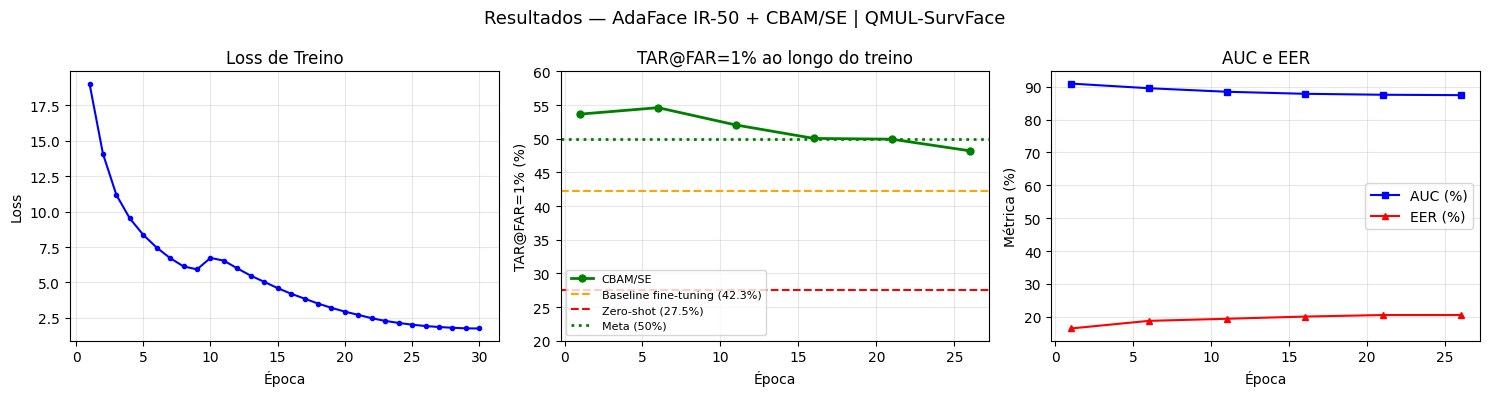

Gráfico salvo em checkpoints_cbam/training_curves.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Resultados — AdaFace IR-50 + CBAM/SE | QMUL-SurvFace', fontsize=13)

# Loss de treino
ax = axes[0]
ax.plot(history['epoch'], history['train_loss'], 'b-o', markersize=3, linewidth=1.5)
ax.set_xlabel('Época')
ax.set_ylabel('Loss')
ax.set_title('Loss de Treino')
ax.grid(alpha=0.3)

# TAR@FAR=1%
eval_epochs = [history['epoch'][i] for i in range(0, len(history['epoch']), EVAL_EVERY)]
if len(eval_epochs) > len(history['tar_at_1pct']):
    eval_epochs = eval_epochs[:len(history['tar_at_1pct'])]

ax = axes[1]
ax.plot(eval_epochs, history['tar_at_1pct'], 'g-o', markersize=5, linewidth=2, label='CBAM/SE')
ax.axhline(y=42.3, color='orange', linestyle='--', label='Baseline fine-tuning (42.3%)')
ax.axhline(y=27.5, color='red',    linestyle='--', label='Zero-shot (27.5%)')
ax.axhline(y=50.0, color='green',  linestyle=':',  label='Meta (50%)', linewidth=2)
ax.set_xlabel('Época')
ax.set_ylabel('TAR@FAR=1% (%)')
ax.set_title('TAR@FAR=1% ao longo do treino')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_ylim(20, 60)

# AUC e EER
ax = axes[2]
ax.plot(eval_epochs, history['auc'], 'b-s', markersize=5, linewidth=1.5, label='AUC (%)')
ax.plot(eval_epochs, history['eer'], 'r-^', markersize=5, linewidth=1.5, label='EER (%)')
ax.set_xlabel('Época')
ax.set_ylabel('Métrica (%)')
ax.set_title('AUC e EER')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico salvo em {OUTPUT_DIR / "training_curves.png"}')

## 10. Curva ROC e resumo final

Carregando melhor checkpoint: best_cbam_ep10_tar54.6.pt
  ⚠ weights_only=True falhou — carregando com weights_only=False (fonte confiável).
Protocolo: 5320 pares genuínos, 5320 pares impostores
Extraindo embeddings de 9913 imagens...
  Embeddings extraídos: 9913
  Pares avaliados: 5320 genuínos, 5320 impostores


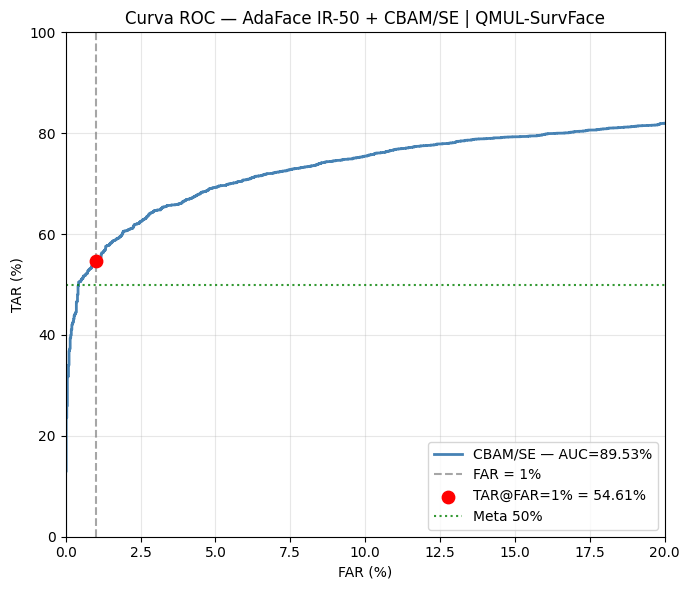


  RESUMO FINAL — AdaFace IR-50 + CBAM/SE
  Zero-shot baseline       : 27.5%
  Fine-tuning simples      : 42.3%
  CBAM/SE (este notebook)  : 54.61%  ← TAR@FAR=1%
  AUC                      : 89.53%
  EER                      : 18.78%
  Meta (> 50%)             : ✓ ATINGIDA


In [20]:
# Carrega melhor checkpoint e gera curva ROC final
best_ckpts = sorted(OUTPUT_DIR.glob('best_cbam_*.pt'),
                    key=lambda p: float(p.stem.split('tar')[-1]))

if best_ckpts and CAN_EVALUATE:
    best_ckpt = best_ckpts[-1]
    print(f'Carregando melhor checkpoint: {best_ckpt.name}')
    ckpt_data = torch.load(best_ckpt, map_location=DEVICE)
    backbone.load_state_dict(ckpt_data['backbone'])
    backbone.eval()

    metrics = evaluate(backbone, TEST_PROBE, TEST_GALLERY, img_size=IMG_SIZE)

    # Curva ROC
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(metrics['fpr'] * 100, metrics['tpr'] * 100,
            color='steelblue', linewidth=2,
            label=f'CBAM/SE — AUC={metrics["AUC"]:.2f}%')
    ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.7, label='FAR = 1%')
    ax.scatter([1.0], [metrics['TAR@FAR1%']],
               color='red', zorder=5, s=80,
               label=f'TAR@FAR=1% = {metrics["TAR@FAR1%"]:.2f}%')
    ax.axhline(y=50.0, color='green', linestyle=':', alpha=0.8, label='Meta 50%')
    ax.set_xlabel('FAR (%)')
    ax.set_ylabel('TAR (%)')
    ax.set_title('Curva ROC — AdaFace IR-50 + CBAM/SE | QMUL-SurvFace')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 20)
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'roc_curve_final.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n' + '='*55)
    print('  RESUMO FINAL — AdaFace IR-50 + CBAM/SE')
    print('='*55)
    print(f'  Zero-shot baseline       : 27.5%')
    print(f'  Fine-tuning simples      : 42.3%')
    print(f'  CBAM/SE (este notebook)  : {metrics["TAR@FAR1%"]:.2f}%  ← TAR@FAR=1%')
    print(f'  AUC                      : {metrics["AUC"]:.2f}%')
    print(f'  EER                      : {metrics["EER"]:.2f}%')
    print(f'  Meta (> 50%)             : {"✓ ATINGIDA" if metrics["TAR@FAR1%"] > 50 else "✗ Ainda não"}')
    print('='*55)
elif not CAN_EVALUATE:
    print('⚠ TEST_PROBE/TEST_GALLERY não disponíveis — não é possível gerar a curva ROC.')
else:
    print('Nenhum checkpoint encontrado. Execute o loop de treino primeiro.')

## 11. Ablation: SE-only vs CBAM-only vs SE+CBAM

Treina três variantes para quantificar a contribuição individual de cada módulo de atenção.

In [21]:
ABLATION_EPOCHS = 10   # treino curto para comparação rápida
ablation_results = {}

if not CAN_EVALUATE:
    print('⚠ TEST_PROBE/TEST_GALLERY não disponíveis — pulando ablation (requer avaliação).')

configs = [
    ('SE only',    {'use_se': True,  'use_cbam': False}),
    ('CBAM only',  {'use_se': False, 'use_cbam': True}),
    ('SE + CBAM',  {'use_se': True,  'use_cbam': True}),
]

for name, cfg in (configs if CAN_EVALUATE else []):
    print(f'\n── Ablation: {name} ──')
    model_abl = IResNet50_CBAM(embed_dim=EMBED_DIM, **cfg).to(DEVICE)
    load_adaface_weights(model_abl, CKPT_PATH, verbose=False)

    loss_abl = AdaFaceLoss(NUM_CLASSES, EMBED_DIM, alpha_clip=ALPHA_CLIP).to(DEVICE)
    opt_abl  = torch.optim.AdamW([
        {'params': model_abl.parameters(), 'lr': LR_BACKBONE},
        {'params': loss_abl.parameters(),  'lr': LR_HEAD},
    ], weight_decay=WEIGHT_DECAY)

    for ep in range(ABLATION_EPOCHS):
        model_abl.train()
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            opt_abl.zero_grad()
            embs, norms = model_abl(imgs)
            loss_abl(embs, norms, labels).backward()
            torch.nn.utils.clip_grad_norm_(model_abl.parameters(), 5.0)
            opt_abl.step()

    model_abl.eval()
    m = evaluate(model_abl, TEST_PROBE, TEST_GALLERY)
    ablation_results[name] = m
    print(f'  TAR@FAR=1%: {m["TAR@FAR1%"]:.2f}%  |  AUC: {m["AUC"]:.2f}%')
    del model_abl, loss_abl, opt_abl

# Tabela comparativa
print('\n── Comparativo ablation ──────────────────────────────')
print(f'{"Configuração":<18} {"TAR@FAR=1%":>12} {"AUC":>8} {"EER":>8}')
print('-' * 50)
for name, m in ablation_results.items():
    print(f'{name:<18} {m["TAR@FAR1%"]:>11.2f}% {m["AUC"]:>7.2f}% {m["EER"]:>7.2f}%')


── Ablation: SE only ──
Protocolo: 5320 pares genuínos, 5320 pares impostores
Extraindo embeddings de 9913 imagens...
  Embeddings extraídos: 9913
  Pares avaliados: 5320 genuínos, 5320 impostores
  TAR@FAR=1%: 53.87%  |  AUC: 88.39%

── Ablation: CBAM only ──
Protocolo: 5320 pares genuínos, 5320 pares impostores
Extraindo embeddings de 9913 imagens...
  Embeddings extraídos: 9913
  Pares avaliados: 5320 genuínos, 5320 impostores
  TAR@FAR=1%: 54.19%  |  AUC: 90.89%

── Ablation: SE + CBAM ──
Protocolo: 5320 pares genuínos, 5320 pares impostores
Extraindo embeddings de 9913 imagens...
  Embeddings extraídos: 9913
  Pares avaliados: 5320 genuínos, 5320 impostores
  TAR@FAR=1%: 53.48%  |  AUC: 89.58%

── Comparativo ablation ──────────────────────────────
Configuração         TAR@FAR=1%      AUC      EER
--------------------------------------------------
SE only                  53.87%   88.39%   19.14%
CBAM only                54.19%   90.89%   16.56%
SE + CBAM                53.48%   

## 12. Exportação do modelo final

Exporta o backbone no formato ONNX para facilitar integração em sistemas de monitoramento.

In [22]:
# Carrega melhor checkpoint
best_ckpts = sorted(OUTPUT_DIR.glob('best_cbam_*.pt'),
                    key=lambda p: float(p.stem.split('tar')[-1]))

if best_ckpts:
    backbone.load_state_dict(torch.load(best_ckpts[-1])['backbone'])
    backbone.eval()

    # Exporta PyTorch state_dict limpo
    torch.save(backbone.state_dict(), OUTPUT_DIR / 'adaface_ir50_cbam_survface.pt')
    print('State dict salvo:', OUTPUT_DIR / 'adaface_ir50_cbam_survface.pt')

    # Exporta ONNX
    dummy = torch.randn(1, 3, 112, 112).to(DEVICE)
    onnx_path = OUTPUT_DIR / 'adaface_ir50_cbam_survface.onnx'
    torch.onnx.export(
        backbone, dummy, onnx_path,
        input_names=['face_image'],
        output_names=['embedding', 'norm'],
        dynamic_axes={'face_image': {0: 'batch_size'}},
        opset_version=17,
        verbose=False,
    )
    print(f'Modelo ONNX exportado: {onnx_path}')
    print(f'Tamanho: {onnx_path.stat().st_size / 1e6:.1f} MB')
else:
    print('Nenhum checkpoint encontrado.')

  ⚠ weights_only=True falhou — carregando com weights_only=False (fonte confiável).
State dict salvo: checkpoints_cbam/adaface_ir50_cbam_survface.pt
Modelo ONNX exportado: checkpoints_cbam/adaface_ir50_cbam_survface.onnx
Tamanho: 176.4 MB
